In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
train = pd.read_csv("thyroid-diag/sick.data", header=None)
test = pd.read_csv("thyroid-diag/sick.test", header=None)

In [3]:
columns = [
'age','sex','on_thyroxine','query_on_thyroxine','on_antithyroid_medication',
'sick_flag','pregnant','thyroid_surgery','I131_treatment','query_hypothyroid',
'query_hyperthyroid','lithium','goitre','tumor','hypopituitary','psych',
'TSH_measured','TSH','T3_measured','T3','TT4_measured','TT4',
'T4U_measured','T4U','FTI_measured','FTI','TBG_measured','TBG',
'referral_source','target'
]

train.columns = columns
test.columns = columns

In [4]:
train = train.drop(columns=['TBG','TBG_measured'])
test = test.drop(columns=['TBG','TBG_measured'])

In [5]:
train.replace("?", np.nan, inplace=True)
test.replace("?", np.nan, inplace=True)

In [6]:
train['target'] = train['target'].str.split('.').str[0]
test['target'] = test['target'].str.split('.').str[0]

In [7]:
numeric_cols = ['age','TSH','T3','TT4','T4U','FTI']

for col in numeric_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

In [8]:
for col in numeric_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

In [9]:
categorical_cols = train.select_dtypes(include='object').columns

for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

In [10]:
categorical_feature_cols = [col for col in train.select_dtypes(include='object').columns if col != 'target']

train_features = pd.get_dummies(train.drop('target', axis=1), columns=categorical_feature_cols, drop_first=True)
test_features = pd.get_dummies(test.drop('target', axis=1), columns=categorical_feature_cols, drop_first=True)

train_features, test_features = train_features.align(test_features, join='left', axis=1, fill_value=0)

train = pd.concat([train_features, train['target']], axis=1)
test = pd.concat([test_features, test['target']], axis=1)

In [11]:
X_train = train.drop('target', axis=1)
y_train = train['target']

X_test = test.drop('target', axis=1)
y_test = test['target']

In [12]:
chi_scores, p_values = chi2(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': chi_scores
})

print(feature_scores.sort_values(by='Score', ascending=False))

                        Feature       Score
0                           age  530.043967
3                           TT4  352.957705
28          referral_source_SVI  186.954463
2                            T3  110.185019
29        referral_source_other   59.577860
10                  sick_flag_t   20.179940
19              hypopituitary_t   15.374269
14          query_hypothyroid_t   10.796240
7                on_thyroxine_t   10.586381
22                T3_measured_t    8.955824
26         referral_source_SVHC    8.821984
5                           FTI    6.657294
4                           T4U    4.547855
6                         sex_M    4.250914
15         query_hyperthyroid_t    3.122262
18                      tumor_t    2.733642
11                   pregnant_t    2.666793
12            thyroid_surgery_t    2.536706
9   on_antithyroid_medication_t    2.211487
21               TSH_measured_t    1.631970
13             I131_treatment_t    1.355331
24               T4U_measured_t 

In [13]:
mean_score = feature_scores['Score'].mean()

selected_features = feature_scores[feature_scores['Score'] > mean_score]['Feature']

print("\nSelected Features:")
print(selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]


Selected Features:
0                       age
2                        T3
3                       TT4
28      referral_source_SVI
29    referral_source_other
Name: Feature, dtype: object


In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train).value_counts())

After SMOTE:
target
negative    2629
sick        2629
Name: count, dtype: int64


/Users/sparshkarna/dev/sem6/ml-lab/myenv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [16]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.9002057613168725


In [17]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.8446502057613169


In [18]:
svm = SVC(kernel='rbf', C=10, gamma=0.1)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.9506172839506173


In [19]:
print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("\nNaive Bayes Report")
print(classification_report(y_test, y_pred_nb))

print("\nSVM Report")
print(classification_report(y_test, y_pred_svm))


Logistic Regression Report
              precision    recall  f1-score   support

    negative       1.00      0.90      0.94       912
        sick       0.38      0.97      0.54        60

    accuracy                           0.90       972
   macro avg       0.69      0.93      0.74       972
weighted avg       0.96      0.90      0.92       972


Naive Bayes Report
              precision    recall  f1-score   support

    negative       0.99      0.84      0.91       912
        sick       0.26      0.85      0.40        60

    accuracy                           0.84       972
   macro avg       0.63      0.85      0.66       972
weighted avg       0.94      0.84      0.88       972


SVM Report
              precision    recall  f1-score   support

    negative       0.99      0.95      0.97       912
        sick       0.56      0.92      0.70        60

    accuracy                           0.95       972
   macro avg       0.78      0.93      0.83       972
weighted avg  

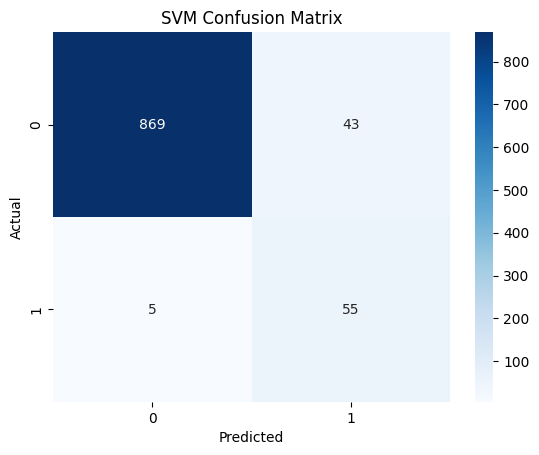

In [20]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

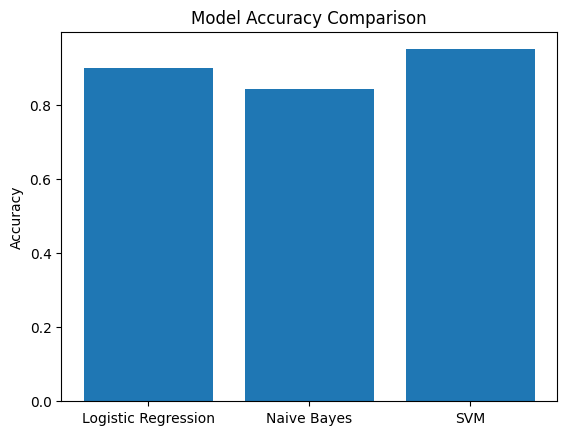

In [21]:
models = ['Logistic Regression','Naive Bayes','SVM']
accuracy = [acc_lr, acc_nb, acc_svm]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()